In [4]:
import matplotlib.pyplot as plt
import numpy as np
def draw_bar(correct_lst, incorrect_lst):
    # Define the bin width
    bins = np.arange(0.5, 1.01, 0.05).tolist()

    # Create the binplot (histogram)
    plt.figure(figsize=(8, 6))
    plt.hist(correct_lst, bins=bins, edgecolor='black', color='green', alpha=0.6, label='Same translation')
    plt.hist(incorrect_lst, bins=bins, edgecolor='black', color='blue', alpha=0.6, label='Different translation')

    # Add labels and title
    plt.xlabel('Value Range')
    plt.ylabel('Counts')
    plt.title(f'Binplot for Exact Match Ratio {lang}')
    plt.legend()
    # Show the plot
    plt.show()

# plt.savefig(f"annotation_results_crawled/binplot_exact_match_ratio_{lang}.jpg", bbox_inches="tight")

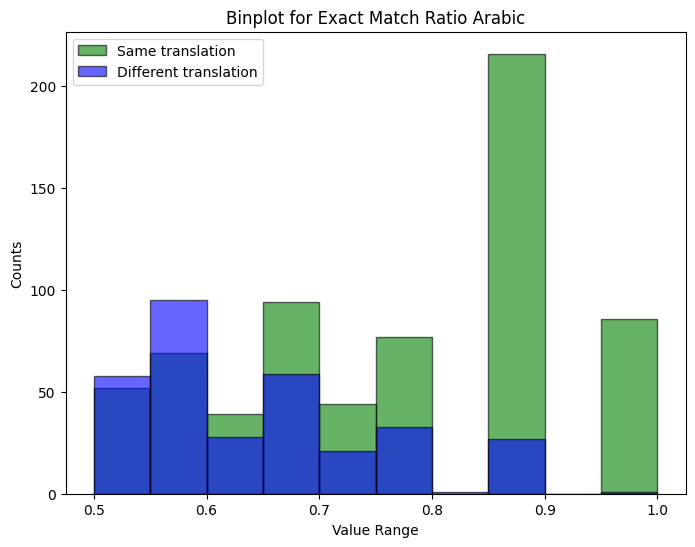

Arabic 1000 677 0.677


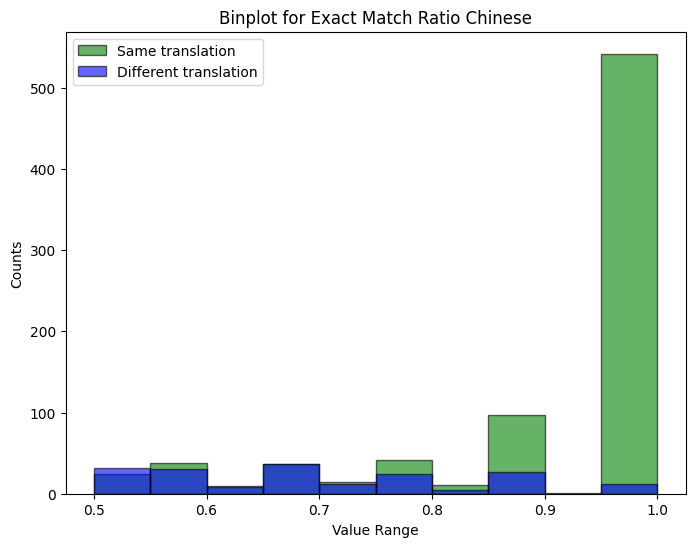

Chinese 1000 815 0.815


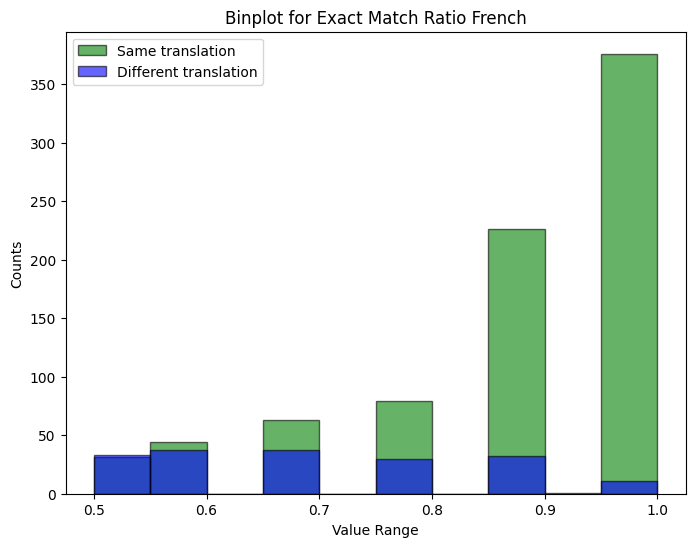

French 1000 820 0.82


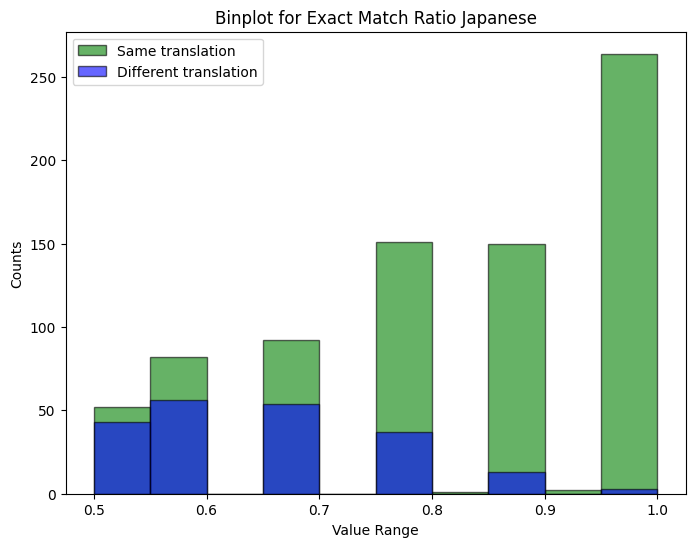

Japanese 1000 794 0.794


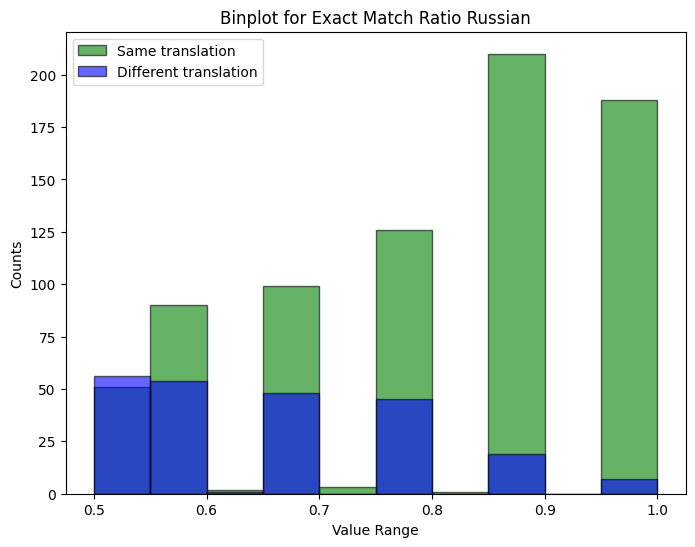

Russian 1000 770 0.77


In [15]:
import pandas as pd
import numpy as np
langs = ['Arabic', 'Chinese', 'French', 'Japanese', 'Russian']
for lang in langs:
    df_gpt = pd.concat([pd.read_csv(f"/home/jiaruil5/multilingual/multilingual-model-card/multilingualmc/dictionary_collection/mturk/analysis/annotation_results_crawled/{lang}_validated_>0.5_sample200-1000.csv"), pd.read_csv(f"/home/jiaruil5/multilingual/multilingual-model-card/multilingualmc/dictionary_collection/mturk/analysis/annotation_results_crawled/{lang}_validated_>0.5_sample200.csv")], ignore_index=True)
    df_major = pd.read_csv(f"/home/jiaruil5/multilingual/multilingual-model-card/multilingualmc/dictionary_collection/mturk/analysis/annotation_results_crawled/{lang}_validated.csv")
    cnt = 0
    cnt_correct = 0
    correct_lst = []
    incorrect_lst = []
    res = []
    for _, row in df_gpt.iterrows():
        if type(row['validated_translation']) == str:
            word_major = df_major[df_major['word'] == row['word']]['validated_translation'].item()
            word_gpt = row['validated_translation']
            if word_major.lower() == word_gpt.lower():
                cnt_correct += 1
                correct_lst.append(eval(row['prediction_ratio'])[0]['ratio'])
            else:
                # print(word_major, word_gpt, row['prediction_ratio'])
                incorrect_lst.append(eval(row['prediction_ratio'])[0]['ratio'])
                
                info = {}
                info['word'] = row['word']
                info['prediction_ratio'] = row['prediction_ratio']
                info['1)validated_translation_by_gpt4o'] = word_gpt
                info['2)word>=0.5'] = word_major
                info['reason'] = row['reason']
                info['back_translations'] = row['back_translations']
                res.append(info)
            cnt += 1
            row_dict = row.to_dict()
            
    draw_bar(correct_lst, incorrect_lst)
    print(lang, cnt, cnt_correct, cnt_correct / cnt)
    pd.DataFrame().from_records(res).to_csv(f"/home/jiaruil5/multilingual/multilingual-model-card/multilingualmc/dictionary_collection/mturk/analysis/annotation_results_crawled/check>0.5new/{lang}.csv")